In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

sns.set_style(style="whitegrid")

FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

EVAL_ROOT = Path("../eval_results")

In [3]:
def latest_rgb_run(eval_root: Path) -> Path:
    runs = [p for p in eval_root.iterdir() if p.is_dir() and p.name.startswith("rgb_")]
    if not runs:
        raise FileNotFoundError(
            f"No RGB eval run folders found in {eval_root}. "
            "Run eval first: python eval.py --modality rgb --ckpt <path>"
        )
    return sorted(runs)[-1]

run_dir = latest_rgb_run(EVAL_ROOT)
run_dir

PosixPath('../eval_results/rgb_rgb_e15_best_20260426_011220')

In [4]:
metrics_path = run_dir / "metrics.json"
report_path = run_dir / "classification_report.json"
cm_path = run_dir / "confusion_matrix.csv"
cmn_path = run_dir / "confusion_matrix_normalized.csv"

with open(metrics_path) as f:
    metrics = json.load(f)
with open(report_path) as f:
    report = json.load(f)
cm = np.loadtxt(cm_path, delimiter=",")
cm_norm = np.loadtxt(cmn_path, delimiter=",")
if cm.ndim == 1:
    cm = cm.reshape(1, -1)
if cm_norm.ndim == 1:
    cm_norm = cm_norm.reshape(1, -1)
num_classes = cm.shape[0]
class_names = [str(i) for i in range(num_classes)]

In [5]:
overall = pd.DataFrame([{
    "accuracy": metrics.get("accuracy"),
    "macro_f1": metrics.get("macro_f1"),
    "weighted_f1": metrics.get("weighted_f1"),
    "balanced_accuracy": metrics.get("balanced_accuracy"),
    "kappa": metrics.get("kappa"),
}]).round(4)

overall

,accuracy,macro_f1,weighted_f1,balanced_accuracy,kappa
0,0.9678,0.9669,0.9678,0.9663,0.9641


In [ ]:
rows = []
for k, v in report.items():
    if isinstance(v, dict) and "precision" in v and "f1-score" in v:
        if k not in ["accuracy", "macro avg", "weighted avg"]:
            rows.append({
                "class": k,
                "precision": v["precision"],
                "f1": v["f1-score"],
                "recall": v["recall"],
                "support": v["support"],
            })

per_class = pd.DataFrame(rows)
per_class = per_class.sort_values("class").reset_index(drop=True)
per_class.round(4)

,class,precision,f1,recall,support
0,0,0.9606,0.9574,0.9543,613.0
1,1,0.9900,0.9884,0.9868,605.0
2,2,0.9320,0.9566,0.9825,628.0
3,3,0.9837,0.9758,0.9679,499.0
4,4,0.9859,0.9751,0.9645,507.0
5,5,0.9515,0.9549,0.9584,409.0
6,6,0.9382,0.9263,0.9148,481.0
7,7,0.9831,0.9889,0.9949,583.0
8,8,0.9625,0.9577,0.9530,511.0
9,9,0.9893,0.9876,0.9858,564.0


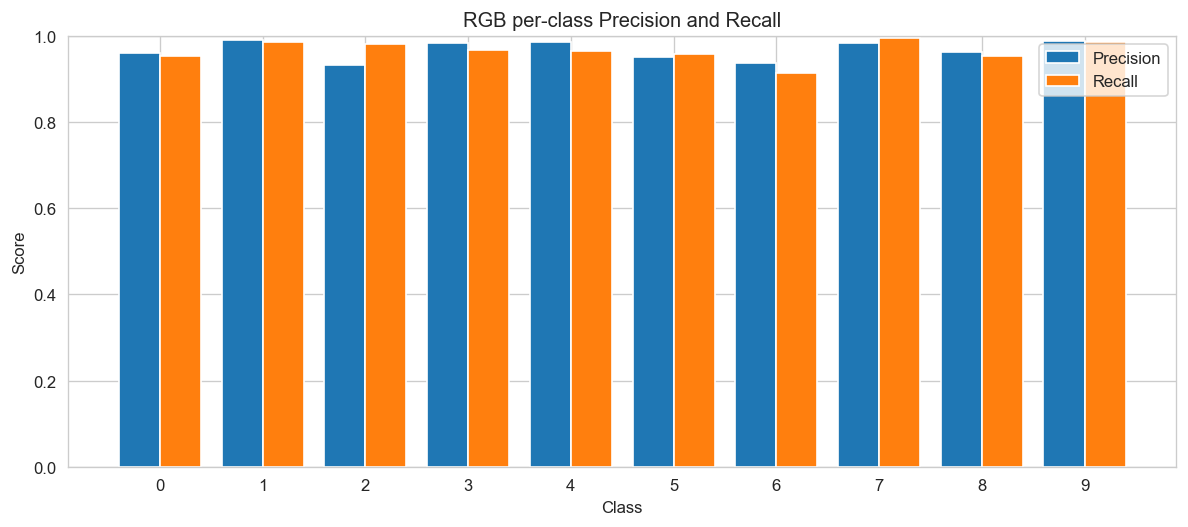

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(per_class))
w = 0.4

ax.bar(x - w/2, per_class["precision"], width=w, label="Precision")
ax.bar(x + w/2, per_class["recall"], width=w, label="Recall")

ax.set_title("RGB per-class Precision and Recall")
ax.set_xlabel("Class")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(per_class["class"])
ax.legend()
fig.tight_layout()

fig.savefig(FIG_DIR / "rgb_eval_precision_recall.png", bbox_inches="tight")
plt.show()

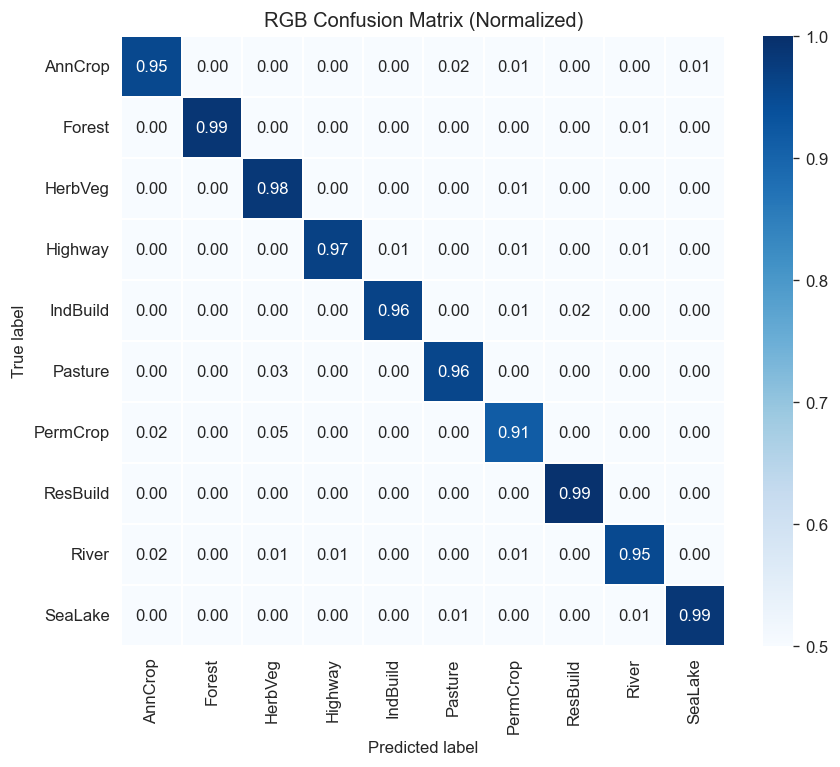

In [8]:
# Same order as class_names: index 0 is class 0 and etc
class_names_short = [
    "AnnCrop", "Forest", "HerbVeg", "Highway", "IndBuild",
    "Pasture", "PermCrop", "ResBuild", "River", "SeaLake"
]

fig, ax = plt.subplots(figsize=(7.5, 6.5))


sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    vmin=0.5, vmax=1,
    cmap="Blues",
    linewidths=1,
    linecolor="white",
    cbar=True,
    xticklabels=class_names_short,
    yticklabels=class_names_short,
    ax=ax
)
ax.set_title("RGB Confusion Matrix (Normalized)")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
fig.tight_layout()

fig.savefig(FIG_DIR / "rgb_confusion_matrix_counts.png", bbox_inches="tight")
plt.show()